# MACHINE LEARNING MINI-PROJECT
### Topic Name : Customer Segmentation
### Group - 3

## Importing Libraries 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import plotly as py
import plotly.graph_objs as go
py.offline.init_notebook_mode(connected=True)

## Exploratory Data Analysis

In [2]:
data = pd.read_csv('datasets/Mall_Customers.csv')

In [3]:
data

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
data.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [7]:
data['Genre'] = data['Genre'].map({'Male': 0, 'Female':1})

In [8]:
data = data.rename(columns={'Genre':'Gender', 'Annual Income (k$)': "Annual Income", 'Spending Score (1-100)': 'Score'})

<Axes: >

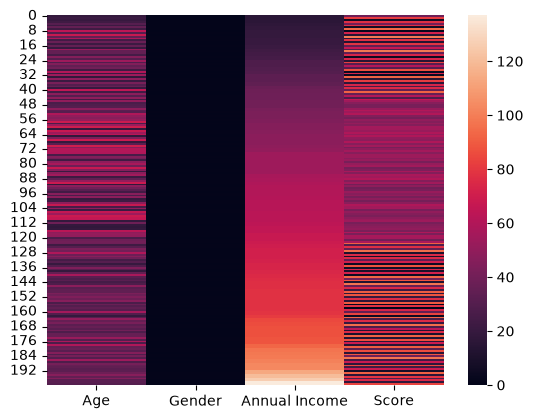

In [9]:
sns.heatmap(data[['Age','Gender' , 'Annual Income', 'Score']])

In [10]:
data[['Age','Gender' , 'Annual Income', 'Score']].corr()

,Age,Gender,Annual Income,Score
Age,1.000000,-0.060867,-0.012398,-0.327227
Gender,-0.060867,1.000000,-0.056410,0.058109
Annual Income,-0.012398,-0.056410,1.000000,0.009903
Score,-0.327227,0.058109,0.009903,1.000000


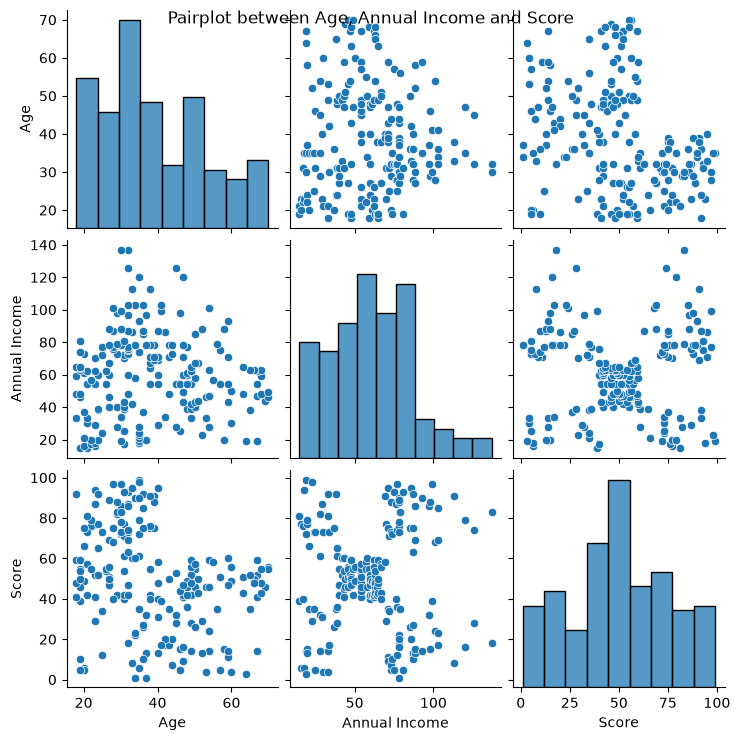

In [11]:
sns.pairplot(data[['Age', 'Annual Income', 'Score']])
plt.suptitle("Pairplot between Age, Annual Income and Score")
plt.show()

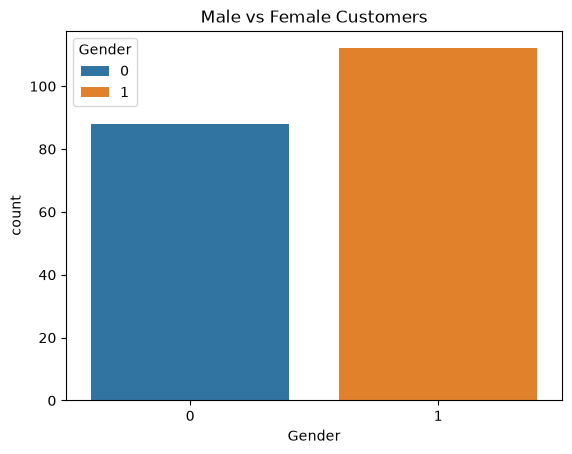

In [12]:
sns.countplot(x='Gender', data= data, hue='Gender')
plt.title("Male vs Female Customers")
plt.show()

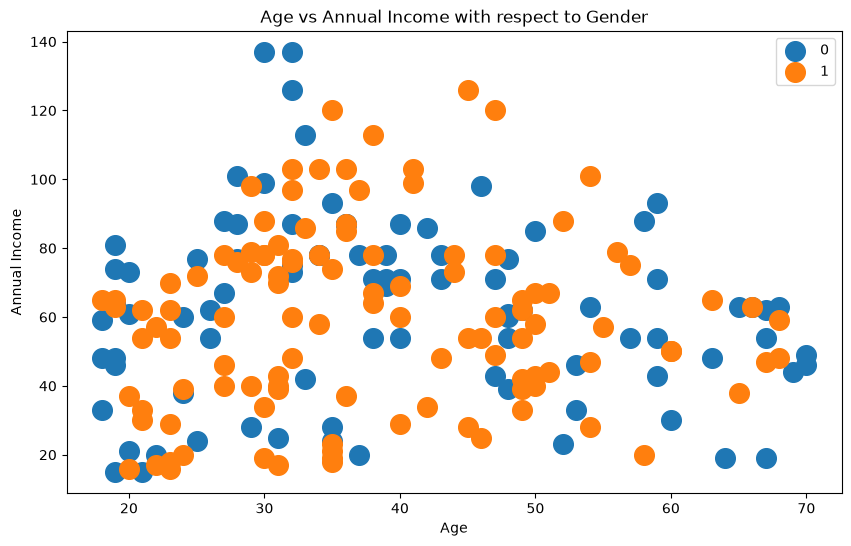

In [13]:
plt.figure(figsize = (10 , 6))
for gender in [0 , 1]:
    plt.scatter(x = 'Age' , y = 'Annual Income' , data = data[data['Gender'] == gender] , s = 200 , label = gender)
plt.xlabel('Age'), plt.ylabel('Annual Income') 
plt.title('Age vs Annual Income with respect to Gender')
plt.legend()
plt.show()

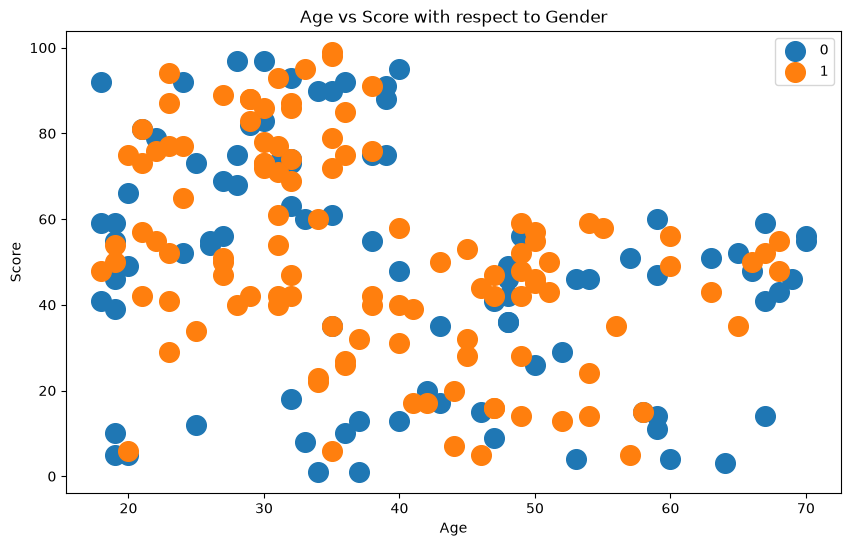

In [14]:
plt.figure(figsize = (10 , 6))
for gender in [0 , 1]:
    plt.scatter(x = 'Age' , y = 'Score' , data = data[data['Gender'] == gender] , s = 200 , label = gender)
plt.xlabel('Age'), plt.ylabel('Score') 
plt.title('Age vs Score with respect to Gender')
plt.legend()
plt.show()

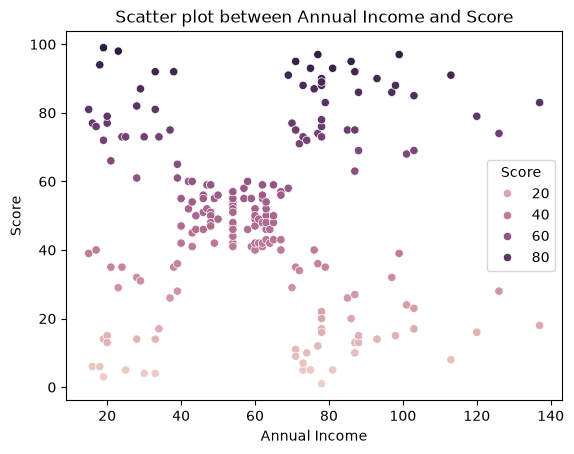

In [15]:
sns.scatterplot(x=data['Annual Income'], y = data['Score'], hue=data['Score'])
plt.title("Scatter plot between Annual Income and Score")
plt.show()

## KMeans Clustering

### Therefore, we can cluster the data using two different parameters:

1. Annual Income and Spending Score
3. Age, Annual Income and Spending Score


#### Clustering data using only Annual Income and Spending Score using the Elbow Method

In [16]:
X = data[['Annual Income', 'Score']]

In [17]:
# wcss stands for Within Cluster Sum of Squares - distance between the point and the assigned centroid.
wcss = []

for i in range (1,11):
    kmeans = KMeans(n_clusters=i, init = 'k-means++', max_iter = 300, n_init=10, random_state= 8)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)  

In [18]:
wcss

[269981.28,
 181363.59595959593,
 106348.37306211119,
 73880.64496247195,
 44448.45544793371,
 37233.814510710006,
 30241.34361793659,
 25061.304119069337,
 21850.16528258563,
 19753.30823618354]

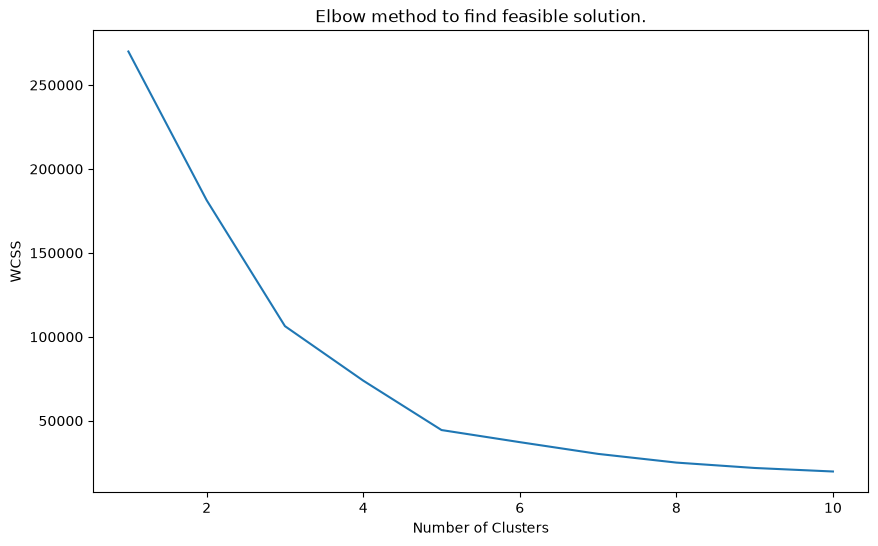

In [19]:
plt.figure(figsize=(10,6))
plt.plot(range(1,11), wcss)
plt.xlabel('Number of Clusters')
plt.ylabel("WCSS")
plt.title("Elbow method to find feasible solution.")
plt.show()

In [20]:
kmeans = KMeans(n_clusters=5, init = 'k-means++', max_iter = 300, random_state= 8)
data['Cluster_AS'] = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

In [21]:
data

,CustomerID,Gender,Age,Annual Income,Score,Cluster_AS
0,1,0,19,15,39,1
1,2,0,21,15,81,3
2,3,1,20,16,6,1
3,4,1,23,16,77,3
4,5,1,31,17,40,1
...,...,...,...,...,...,...
195,196,1,35,120,79,2
196,197,1,45,126,28,0
197,198,0,32,126,74,2
198,199,0,32,137,18,0


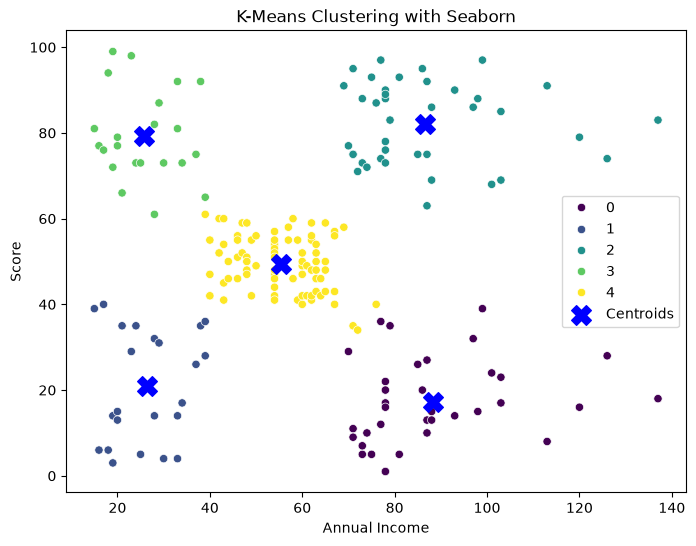

In [22]:
plt.figure(figsize=(8, 6))

# Scatter plot of Annual Income with Score
sns.scatterplot(
    x="Annual Income", y="Score", hue="Cluster_AS", palette="viridis", data=data
)

# Superpositioning Cluster Centroid on top of above Scatter plot
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c="blue",
    s=200,
    marker="X",
    label="Centroids",
)

plt.title("K-Means Clustering with Seaborn")
plt.legend()
plt.show()


#### Clustering data using Age, Annual Income and Spending Score using the Elbow Method

In [23]:
X1 = data[['Age', 'Annual Income', 'Score']]

In [24]:
wcss2 = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter =300, random_state=8)
    kmeans.fit(X1)
    wcss2.append(kmeans.inertia_)

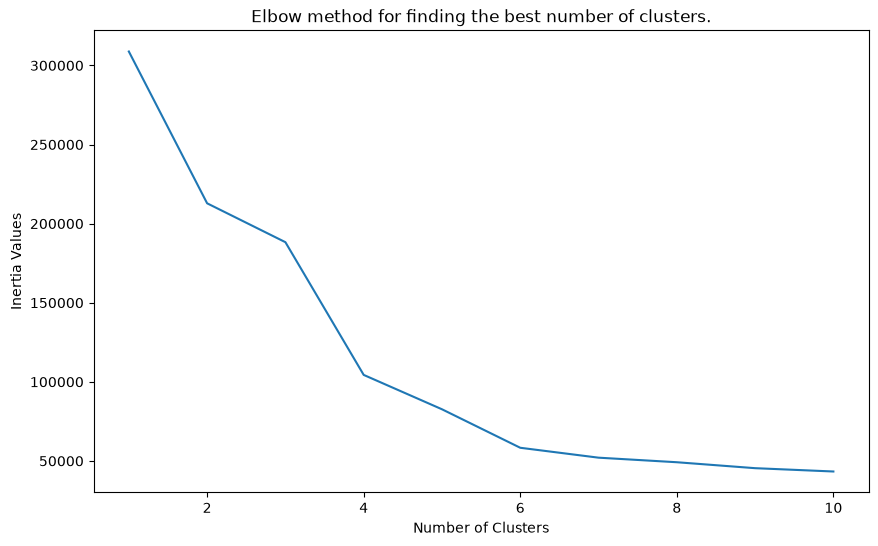

In [25]:
plt.figure(figsize = (10,6))
plt.plot(range(1,11),wcss2)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia Values")
plt.title("Elbow method for finding the best number of clusters.")
plt.show()

In [26]:
kmeans = KMeans(n_clusters=6, init='k-means++', random_state=8)
data['Clusters_AAS'] = kmeans.fit_predict(X1)
centroids2 = kmeans.cluster_centers_

In [27]:
trace1 = go.Scatter3d(
    x= data['Age'],
    y= data['Score'],
    z= data['Annual Income'],
    mode='markers',
     marker=dict(
        color = data['Clusters_AAS'], 
        size= 20,
        line=dict(
            color= data['Clusters_AAS'],
            width= 12
        ),
        opacity=0.8
     )
)
df = [trace1]
layout = go.Layout(

    title= 'Clusters',
    scene = dict(
            xaxis = dict(title  = 'Age'),
            yaxis = dict(title  = 'Spending Score'),
            zaxis = dict(title  = 'Annual Income')
        )
)

fig = go.Figure(data=[trace1], layout=layout)
fig.show()

## Comparision between KMeans, DBSCAN and Heirarchiral Clustering

In [28]:
from sklearn.preprocessing import StandardScaler #For standardizing each data
from sklearn.decomposition import PCA #For matrix decomposition
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN #Importing the main algorithms
from sklearn.neighbors import NearestNeighbors 
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score)

scaled_features = StandardScaler().fit_transform(X)
pca_coordinates = PCA(n_components=2).fit_transform(scaled_features)
optimal_k = 5
comparison_rows = []

#### K-Means

In [29]:
kmeans_model = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
kmeans_labels = kmeans_model.fit_predict(scaled_features)

comparison_rows.append({
    "algorithm": "K-Means",
    "clusters": len(set(kmeans_labels)),
    "noise_percent": 0.0,
    "silhouette": silhouette_score(scaled_features, kmeans_labels),
    "davies_bouldin": davies_bouldin_score(scaled_features, kmeans_labels),
    "calinski_harabasz": calinski_harabasz_score(scaled_features, kmeans_labels),
})

#### Hierarchiral Clustering

In [30]:
hierarchical_model = AgglomerativeClustering(n_clusters=optimal_k, linkage="ward")
hierarchical_labels = hierarchical_model.fit_predict(scaled_features)

comparison_rows.append({
    "algorithm": "Hierarchical",
    "clusters": len(set(hierarchical_labels)),
    "noise_percent": 0.0,
    "silhouette": silhouette_score(scaled_features, hierarchical_labels),
    "davies_bouldin": davies_bouldin_score(scaled_features, hierarchical_labels),
    "calinski_harabasz": calinski_harabasz_score(scaled_features, hierarchical_labels),
})

#### DBSCAN

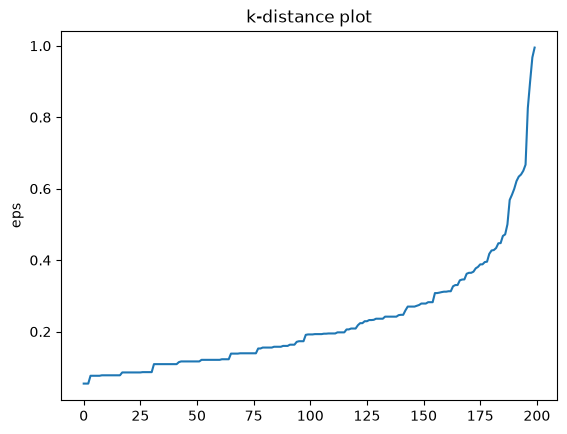

In [31]:
dbscan_min_samples = 2 * scaled_features.shape[1]

neighbors_model = NearestNeighbors(n_neighbors=dbscan_min_samples).fit(scaled_features)
neighbor_distances, _ = neighbors_model.kneighbors(scaled_features)
sorted_k_distances = np.sort(neighbor_distances[:, -1])

plt.plot(sorted_k_distances)
plt.title("k-distance plot")
plt.ylabel("eps")
plt.show()

In [32]:
dbscan_eps = 0.8  # set from the elbow in the plot above

dbscan_model = DBSCAN(eps=dbscan_eps, min_samples=dbscan_min_samples)
dbscan_labels = dbscan_model.fit_predict(scaled_features)

non_noise_mask = dbscan_labels != -1
dbscan_cluster_count = len(set(dbscan_labels[non_noise_mask]))

dbscan_row = {
    "algorithm": "DBSCAN",
    "clusters": dbscan_cluster_count,
    "noise_percent": 100 * (~non_noise_mask).mean(),
}
if dbscan_cluster_count > 1:
    dbscan_row["silhouette"] = silhouette_score(scaled_features[non_noise_mask], dbscan_labels[non_noise_mask])
    dbscan_row["davies_bouldin"] = davies_bouldin_score(scaled_features[non_noise_mask], dbscan_labels[non_noise_mask])
    dbscan_row["calinski_harabasz"] = calinski_harabasz_score(scaled_features[non_noise_mask], dbscan_labels[non_noise_mask])

comparison_rows.append(dbscan_row)

### Comparision

In [33]:
comparison_table = pd.DataFrame(comparison_rows).round(3)
comparison_table

,algorithm,clusters,noise_percent,silhouette,davies_bouldin,calinski_harabasz
0,K-Means,5,0.0,0.555,0.572,248.649
1,Hierarchical,5,0.0,0.554,0.578,244.410
2,DBSCAN,1,0.0,NaN,NaN,NaN


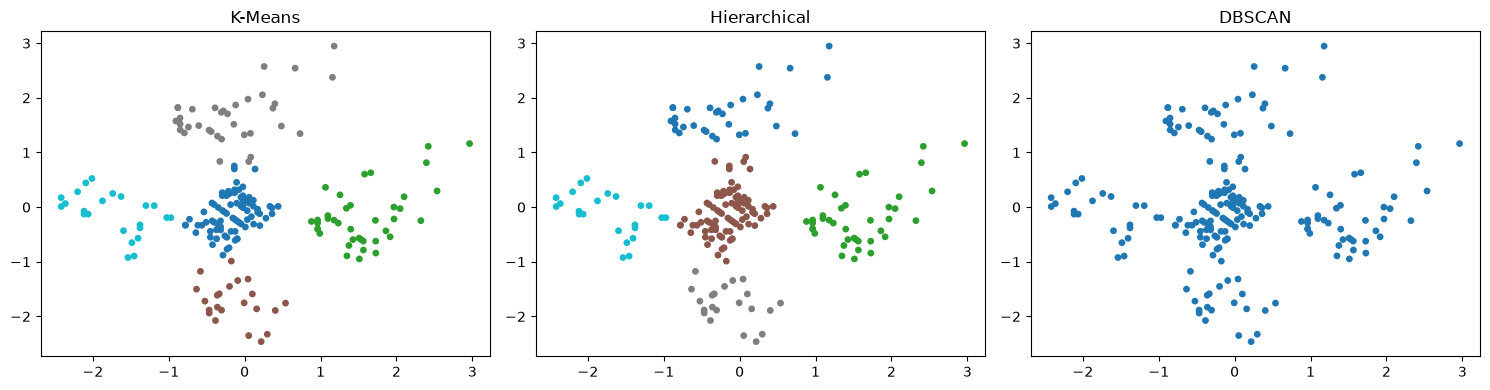

In [34]:
all_labels = {
    "K-Means": kmeans_labels,
    "Hierarchical": hierarchical_labels,
    "DBSCAN": dbscan_labels,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, (algorithm_name, labels) in zip(axes, all_labels.items()):
    axis.scatter(pca_coordinates[:, 0], pca_coordinates[:, 1], c=labels, cmap="tab10", s=15)
    axis.set_title(algorithm_name)
plt.tight_layout()
plt.show()

In [35]:
print("ARI K-Means vs Hierarchical:", adjusted_rand_score(kmeans_labels, hierarchical_labels))
print("ARI K-Means vs DBSCAN:", adjusted_rand_score(kmeans_labels, dbscan_labels))

ARI K-Means vs Hierarchical: 0.9419606318143182
ARI K-Means vs DBSCAN: 0.0
